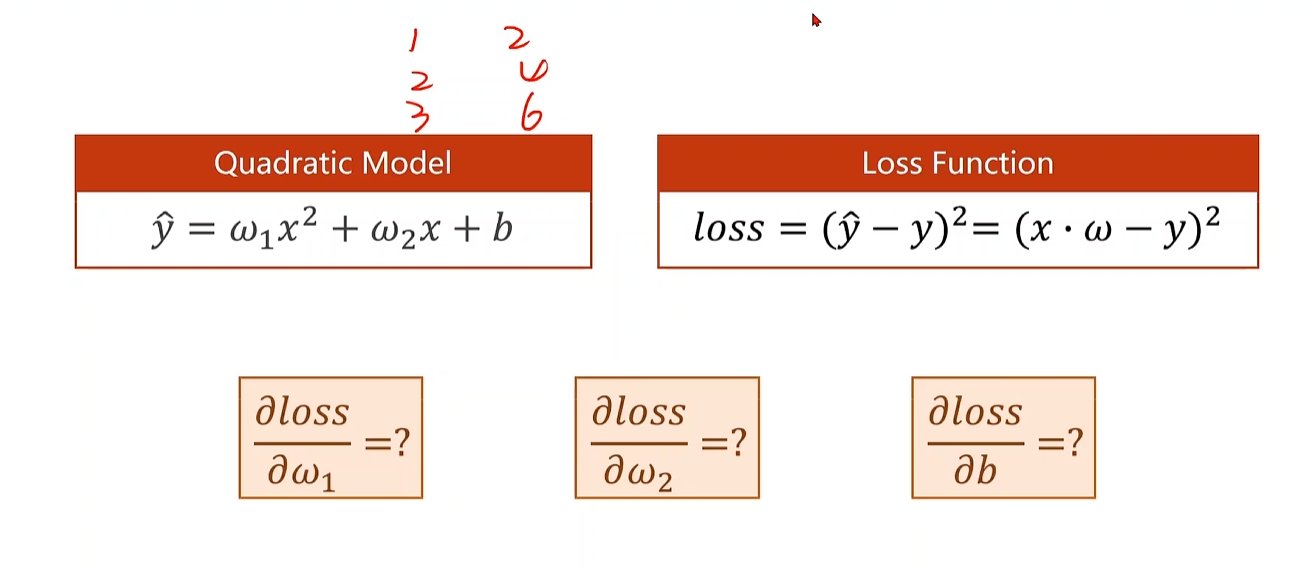

In [ ]:
import torch

x_data = torch.tensor([1.0,2.0,3.0])
y_data = torch.tensor([2.0,4.0,6.0])

w1= torch.tensor([1.0], requires_grad=True)
w2= torch.tensor([1.0], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

def forward(x):
    return w1 * x * x + w2 * x + b

def loss(x, y):
    y_pred = forward(x)
    return (y_pred - y).pow(2).mean()

print("predict (before training)", 4, forward(4).item())

for epoch in range(100):
    for x_val, y_val in zip(x_data, y_data):
        l = loss(x_val, y_val)
        l.backward()
        print(x_val.item(), y_val.item(), w1.item(), w2.item(), b.item(), l.item())
        w1.data -= 0.01 * w1.grad.data
        w2.data -= 0.01 * w2.grad.data
        b.data -= 0.01 * b.grad.data

        w1.grad.data.zero_()
        w2.grad.data.zero_()
        b.grad.data.zero_()

        print("progress:", epoch, l.item())

print("predict (after training)", 4, forward(4).item())

In [ ]:
import torch

x_data = torch.tensor([1.0,2.0,3.0])
y_data = torch.tensor([2.0,4.0,6.0])

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # 输入和输出都是1维

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

criterion = torch.nn.MSELoss()  # 均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 随机梯度下降优化器

for epoch in range(1000):
    y_pred = model(x_data.view(-1, 1))  # 前向传播
    loss = criterion(y_pred, y_data.view(-1, 1))  #计算损失
    optimizer.zero_grad()  # 清空梯度
    loss.backward()  # 反向传播
    optimizer.step()  # 更新参数

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}')

# 打印训练完的 w 和 b
w = model.linear.weight.item()
b = model.linear.bias.item()
print(f"\n训练结果: w = {w:.4f}, b = {b:.4f}")

In [ ]:
import torch

x_raw = torch.tensor([1.0,2.0,3.0])
y_data = torch.tensor([2.0,4.0,6.0])

x1 = x_raw.view(-1,1)  # 将x_raw转换为二维张量，形状为[3,1]
x2 = (x_raw ** 2).view(-1,1)  # 将x_raw的平方转换为二维张量，形状为[3,1]
x_data = torch.cat([x1,x2],dim=1)  # 将x1和x2按列拼接，得到形状为[3,2]的二维张量

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(2, 1)  # 输入特征为2，输出为1

    def forward(self, x):
        return self.linear(x)  # 前向传播，返回线性输出

model = LinearRegressionModel()
criterion = torch.nn.MSELoss()  # 均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 随机梯度下降优化器，学习率为0.01

for epoch in range(1000):  # 训练1000轮
    y_pred = model(x_data)  # 前向传播，得到预测值
    loss = criterion(y_pred, y_data.view(-1,1))  # 计算损失，y_data需要转换为二维张量
    optimizer.zero_grad()  # 梯度清零
    loss.backward()  # 反向传播，计算梯度
    optimizer.step()  # 更新参数

    if (epoch+1) % 100 == 0:  # 每100轮打印一次损失
        print(f'Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}')

print(f'Final parameters: w1={model.linear.weight[0][0].item():.4f}, w2={model.linear.weight[0][1].item():.4f}, b={model.linear.bias.item():.4f}')